<a href="https://www.kaggle.com/code/aamir28/diabetes-risk-prediction-an-audit?scriptVersionId=346171357" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 42%, #c98a2b 75%, #e8c468 100%);
    padding: 40px 36px;
    border-radius: 14px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    text-align: left;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 3px;
    text-transform: uppercase;
">50,000 Patient Records &middot; 41 Columns &middot; EDA Notebook</span>
<h1 style="
    color:#ffffff;
    font-size: 34px;
    font-weight: 800;
    margin: 12px 0 10px 0;
    letter-spacing: -0.5px;
">Diabetes Risk Prediction: An Audit, Not Just an Exploration</h1>
<p style="
    color: rgba(255,255,255,0.9);
    font-size: 16px;
    max-width: 640px;
    margin: 0 0 18px 0;
    line-height: 1.5;
">
A large, clean-looking synthetic health dataset that turns out to need real scrutiny &mdash; this notebook walks through what a careless analysis would miss: target leakage, severe class imbalance, and features that look clinical but carry almost no real signal.
</p>
<div style="display:flex; gap:28px; margin-top:10px;">
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">50,000</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Rows</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">41</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Columns</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">73.2%</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">"High" Risk</div>
  </div>
</div>
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 01</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Setup &amp; Data Load</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Import libraries and load the CSV.</p>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Theme colors matching the dataset's banner (warm charcoal -> pale straw)
CHARCOAL, UMBER, AMBER, STRAW, TEAL = '#22201b', '#4a3a1f', '#c98a2b', '#e8c468', '#2c7d78'

df = pd.read_csv('/kaggle/input/datasets/mobeenfatimah/diabetes-risk-prediction-dataset-50k-patients/diabetes_risk_prediction_dataset.csv')
df.shape

(50000, 41)

<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 02</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Data Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check structure, types, and get a first look at all 41 columns.</p>
</div>


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  50000 non-null  int64  
 1   Age                         49503 non-null  float64
 2   Gender                      50000 non-null  object 
 3   Country                     50000 non-null  object 
 4   Height_cm                   47055 non-null  float64
 5   Weight_kg                   47038 non-null  float64
 6   BMI                         50000 non-null  float64
 7   Waist_Circumference_cm      50000 non-null  float64
 8   Blood_Glucose               49041 non-null  float64
 9   HbA1c                       48026 non-null  float64
 10  Fasting_Blood_Sugar         50000 non-null  float64
 11  Insulin_Level               50000 non-null  float64
 12  Blood_Pressure_Systolic     50000 non-null  int64  
 13  Blood_Pressure_Diastolic    500

<div style="
    border-left: 4px solid #2c7d78;
    background: #eef6f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1a2422;
">
<b style="color:#2c7d78; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A large table: <b>50,000 rows &times; 41 columns</b>. Each row is one patient, covering demographics, body measurements, blood-panel results, lifestyle habits, and a <code>Diabetes_Risk</code> label. Three columns &mdash; <code>Diabetes_Risk_Score</code>, <code>AI_Health_Recommendation</code>, and <code>Doctor_Consultation_Needed</code> &mdash; look, just from their names, like they could be outputs derived from the risk label rather than independent predictors of it. The next section checks that directly before those columns go anywhere near a model.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 03</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Target Distribution</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check the balance of the Diabetes_Risk classes before anything else — this shapes how every later metric should be read.</p>
</div>


In [3]:
risk_counts = df['Diabetes_Risk'].value_counts()
print(risk_counts)
print()
print((risk_counts / len(df) * 100).round(2))

Diabetes_Risk
High        36593
Moderate    12937
Low           470
Name: count, dtype: int64

Diabetes_Risk
High        73.19
Moderate    25.87
Low          0.94
Name: count, dtype: float64


<div style="
    border-left: 4px solid #c98a2b;
    background: #fbf1e0;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #2a2114;
">
<b style="color:#a8701f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Data Quality Flag</b><br>
This target is severely imbalanced: <b>73.2% High</b>, <b>25.9% Moderate</b>, and just <b>0.94% Low</b> &mdash; fewer than 1 in 100 patients. A model that always predicted "High" would already be right nearly three-quarters of the time. Keep this in mind for every accuracy number in this notebook: plain accuracy will look deceptively strong regardless of whether a model has learned anything about the minority classes.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 04</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Checking the Suspicious Columns</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Test directly whether Diabetes_Risk_Score is actually independent of Diabetes_Risk, or whether one was used to construct the other.</p>
</div>


In [4]:
df.groupby('Diabetes_Risk')['Diabetes_Risk_Score'].describe()[['min', 'max', 'mean']]

,min,max,mean
Diabetes_Risk,,,
High,65.0,100.0,81.409122
Low,13.0,34.0,29.236170
Moderate,35.0,64.0,54.838912


<div style="
    border-left: 4px solid #c98a2b;
    background: #fbf1e0;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #2a2114;
">
<b style="color:#a8701f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Data Quality Flag</b><br>
This confirms direct leakage, not just correlation: <code>Diabetes_Risk_Score</code> brackets <code>Diabetes_Risk</code> with <b>zero overlap</b> &mdash; Low is always 13&ndash;34, Moderate is always 35&ndash;64, High is always 65&ndash;100. One of these columns was almost certainly used to construct the other. Including <code>Diabetes_Risk_Score</code> as a model "feature" would let a classifier reach trivial, meaningless near-100% accuracy by essentially looking up the answer. The next check confirms the other two suspicious columns are the same kind of problem.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 05</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Confirming the Other Two Leakage Columns</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">AI_Health_Recommendation and Doctor_Consultation_Needed look like consequences of the risk label rather than inputs to it — check that directly too.</p>
</div>


In [5]:
print(pd.crosstab(df['Diabetes_Risk'], df['Doctor_Consultation_Needed']))
print()
for tier in ['Low', 'Moderate', 'High']:
    cats = sorted(df.loc[df['Diabetes_Risk'] == tier, 'AI_Health_Recommendation'].unique())
    print(f"{tier}: {cats}")

Doctor_Consultation_Needed    No    Yes
Diabetes_Risk                          
High                           0  36593
Low                          417     53
Moderate                    3157   9780

Low: ['Annual Diabetes Screening', 'Balanced Diet', 'Exercise Regularly', 'Maintain Healthy Lifestyle', 'Routine Health Checkup']
Moderate: ['Healthy Diet Plan', 'Increase Physical Activity', 'Monitor Blood Glucose', 'Reduce Sugar Intake', 'Weight Management Program']
High: ['Begin Diabetes Management Plan', 'Consult Endocrinologist Immediately', 'Immediate Lifestyle Intervention', 'Medical Evaluation Required', 'Strict Blood Sugar Monitoring']


<div style="
    border-left: 4px solid #c98a2b;
    background: #fbf1e0;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #2a2114;
">
<b style="color:#a8701f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Data Quality Flag</b><br>
Every single <b>High</b>-risk patient is marked <code>Doctor_Consultation_Needed = Yes</code> (36,593 of 36,593) &mdash; this is a business rule applied <i>because of</i> the risk label, not a clinical input that predicts it. <code>AI_Health_Recommendation</code> shows the same pattern even more clearly: each risk tier draws from its own <b>completely separate</b> set of five recommendation phrases &mdash; Low gets things like "Exercise Regularly" and "Routine Health Checkup," while High gets "Consult Endocrinologist Immediately" and "Strict Blood Sugar Monitoring." No phrase appears in more than one tier. This is unmistakably output text generated from the risk label, not an independent signal that predicts it. All three flagged columns are excluded from every analysis and every model in the rest of this notebook &mdash; they describe what happens <i>after</i> a risk tier is assigned, not what predicts it.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 06</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Missingness</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Quantify which of the remaining, legitimate columns have gaps.</p>
</div>


In [6]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

Weight_kg                  2962
Height_cm                  2945
Sleep_Hours                2017
Exercise_Hours_Per_Week    1992
HbA1c                      1974
Daily_Walking_Minutes      1964
LDL                        1000
Triglycerides              1000
Total_Cholesterol          1000
HDL                        1000
Medication_Adherence       1000
Blood_Glucose               959
Physical_Activity_Level     500
Age                         497
dtype: int64

<div style="
    border-left: 4px solid #2c7d78;
    background: #eef6f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1a2422;
">
<b style="color:#2c7d78; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Missingness is spread across <b>14 different columns</b>, ranging from about <b>1%</b> (Age, Physical_Activity_Level) up to nearly <b>6%</b> (Weight_kg, Height_cm) &mdash; broader and more evenly distributed than a dataset with one or two problem columns. No single column is missing enough to drop entirely, but the model section later in this notebook needs to handle these gaps explicitly rather than assume a complete table.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 07</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Categorical Label Scan</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check every categorical column for inconsistent casing, whitespace, or near-duplicate labels.</p>
</div>


In [7]:
cat_cols = ['Gender', 'Physical_Activity_Level', 'Diet_Quality', 'Sugar_Intake_Level', 'Stress_Level',
            'Smoking_Status', 'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension',
            'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence', 'Work_Type', 'Residence_Type']

inconsistencies = {}
for col in cat_cols:
    vals = df[col].dropna().unique()
    lower_groups = {}
    for v in vals:
        lower_groups.setdefault(str(v).strip().lower(), []).append(v)
    dupes = {k: v for k, v in lower_groups.items() if len(v) > 1}
    if dupes:
        inconsistencies[col] = dupes

inconsistencies if inconsistencies else "No case/whitespace inconsistencies found across any categorical column." 

'No case/whitespace inconsistencies found across any categorical column.'

<div style="
    border-left: 4px solid #2c7d78;
    background: #eef6f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1a2422;
">
<b style="color:#2c7d78; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Zero label inconsistencies across all 15 categorical columns checked. Whatever issues this dataset has, inconsistent labeling isn't one of them.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 08</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Second Data Quality Flag: PCOS by Gender</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">PCOS (polycystic ovary syndrome) is a condition specific to people with ovaries. Check whether the data respects that.</p>
</div>


In [8]:
pd.crosstab(df['Gender'], df['PCOS'])

PCOS,No,Yes
Gender,,
Female,8358,8247
Male,8375,8343
Other,8338,8339


<div style="
    border-left: 4px solid #c98a2b;
    background: #fbf1e0;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #2a2114;
">
<b style="color:#a8701f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Data Quality Flag</b><br>
PCOS is assigned at essentially the same ~50% rate across <b>Male</b>, <b>Female</b>, and <b>Other</b> &mdash; roughly 8,340-8,375 "Yes" and "No" in every group. Medically, this column shouldn't apply to male patients at all. This is a sign the dataset's categorical fields were generated independently of each other rather than through a coherent underlying simulation &mdash; worth knowing before treating any PCOS-related pattern in this data as a real clinical finding.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 09</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Do the Clinical Variables Even Relate to Each Other?</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Before looking for what predicts diabetes risk, check some pairs that should be related for basic physiological reasons — if these are also near-zero, it says something important about the whole dataset.</p>
</div>


In [9]:
pairs_to_check = [
    ('BMI', 'Waist_Circumference_cm'),
    ('Total_Cholesterol', 'LDL'),
    ('Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic'),
    ('Fasting_Blood_Sugar', 'HbA1c'),
    ('Exercise_Hours_Per_Week', 'Daily_Walking_Minutes'),
]

for a, b in pairs_to_check:
    print(f"{a} vs {b}: {df[a].corr(df[b]):.3f}")

BMI vs Waist_Circumference_cm: -0.006
Total_Cholesterol vs LDL: -0.004
Blood_Pressure_Systolic vs Blood_Pressure_Diastolic: 0.000
Fasting_Blood_Sugar vs HbA1c: -0.005
Exercise_Hours_Per_Week vs Daily_Walking_Minutes: -0.003


<div style="
    border-left: 4px solid #c98a2b;
    background: #fbf1e0;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #2a2114;
">
<b style="color:#a8701f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Data Quality Flag</b><br>
Every one of these pairs &mdash; each a relationship that holds reliably in real health data (a higher BMI usually comes with a larger waist; systolic and diastolic blood pressure move together; fasting blood sugar and HbA1c both reflect blood glucose control) &mdash; comes out at essentially <b>zero correlation</b> here. This isn't one or two unlucky pairs; it's a consistent pattern indicating the numeric clinical fields in this dataset were generated independently of one another, not from a shared underlying patient physiology. That doesn't make the dataset useless, but it does mean this notebook treats any single-variable relationship it finds as a standalone, weak signal rather than part of a richer clinical story &mdash; because there isn't one to find here.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 10</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">What Actually Has Any Signal</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Given the last two sections, check honestly: does anything legitimate correlate with Diabetes_Risk at all?</p>
</div>


In [10]:
risk_map = {'Low': 0, 'Moderate': 1, 'High': 2}
df['risk_ord'] = df['Diabetes_Risk'].map(risk_map)

numeric_cols = ['Age', 'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar',
                'Insulin_Level', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Total_Cholesterol',
                'HDL', 'LDL', 'Triglycerides', 'Heart_Rate', 'Exercise_Hours_Per_Week', 'Sleep_Hours']

corrs = df[numeric_cols].corrwith(df['risk_ord']).sort_values(key=abs, ascending=False)
corrs.round(3)

Fasting_Blood_Sugar         0.380
HbA1c                       0.275
Age                         0.211
BMI                         0.161
Blood_Pressure_Systolic     0.120
Total_Cholesterol           0.094
Blood_Pressure_Diastolic    0.073
Sleep_Hours                -0.050
Blood_Glucose               0.005
Waist_Circumference_cm     -0.005
Insulin_Level              -0.004
LDL                        -0.004
HDL                         0.001
Triglycerides               0.000
Heart_Rate                  0.000
Exercise_Hours_Per_Week     0.000
dtype: float64

<div style="
    border-left: 4px solid #2c7d78;
    background: #eef6f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1a2422;
">
<b style="color:#2c7d78; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Something does, though modestly: <b>Fasting_Blood_Sugar</b> (r=0.38) and <b>HbA1c</b> (r=0.28) are the strongest numeric predictors, followed by <b>Age</b> (0.21) and <b>BMI</b> (0.16). Everything past that &mdash; waist circumference, insulin, cholesterol markers, heart rate, exercise, sleep &mdash; sits close enough to zero to be indistinguishable from noise. These top values are also noticeably weaker than what a genuinely clinical dataset tends to show for the same kind of measurement; treat them as the real, if modest, signal in this data rather than as strong predictors.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 11</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Categorical Variables: Same Pattern</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check the spread in mean risk level across categories for several plausible lifestyle and history variables.</p>
</div>


In [11]:
cat_check = ['Family_History_Diabetes', 'Smoking_Status', 'Hypertension', 'Diet_Quality',
             'Sugar_Intake_Level', 'Physical_Activity_Level']

for col in cat_check:
    means = df.groupby(col)['risk_ord'].mean()
    print(f"{col}: spread = {means.max() - means.min():.3f}")

Family_History_Diabetes: spread = 0.206
Smoking_Status: spread = 0.104
Hypertension: spread = 0.129
Diet_Quality: spread = 0.124
Sugar_Intake_Level: spread = 0.004
Physical_Activity_Level: spread = 0.127


<div style="
    border-left: 4px solid #2c7d78;
    background: #eef6f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1a2422;
">
<b style="color:#2c7d78; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>Family_History_Diabetes</b> shows the largest spread of any categorical variable (0.206) &mdash; small, but the one categorical relationship that's both real and clinically sensible to find. Notably, <b>Sugar_Intake_Level</b> &mdash; a variable you'd expect to matter directly for diabetes risk &mdash; shows almost no spread at all (0.004), reinforcing the pattern found throughout this notebook: most of this dataset's lifestyle fields don't meaningfully move the risk label.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 12</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Correlation Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">See the near-independence finding all at once, across the core numeric variables.</p>
</div>


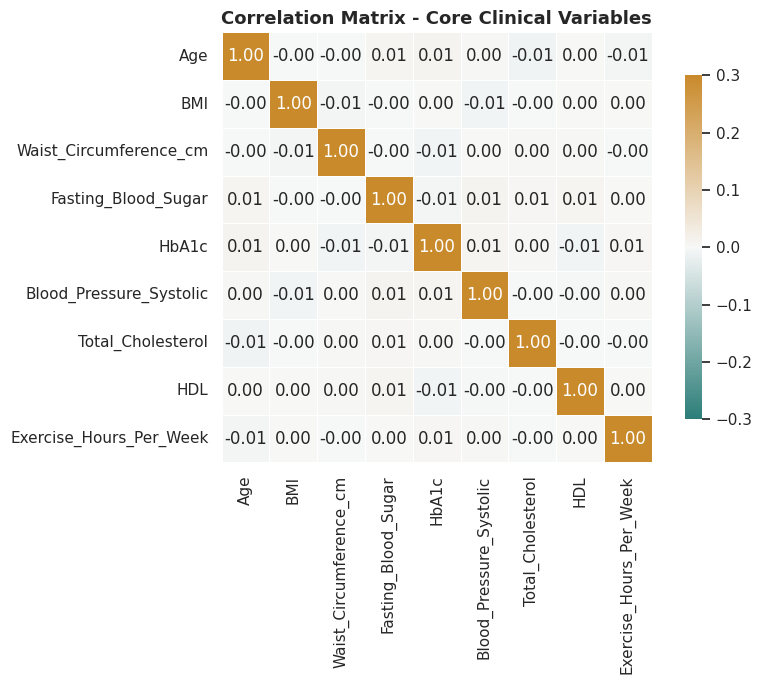

In [12]:
corr_subset = df[['Age', 'BMI', 'Waist_Circumference_cm', 'Fasting_Blood_Sugar', 'HbA1c',
                  'Blood_Pressure_Systolic', 'Total_Cholesterol', 'HDL', 'Exercise_Hours_Per_Week']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap=sns.blend_palette([TEAL, '#f7f7f7', AMBER], as_cmap=True),
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, vmin=-0.3, vmax=0.3, ax=ax)
ax.set_title('Correlation Matrix - Core Clinical Variables', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2c7d78;
    background: #eef6f5;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1a2422;
">
<b style="color:#2c7d78; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
This heatmap looks unusually flat for a clinical dataset &mdash; and that flatness is itself the finding, not a rendering issue. The color scale is intentionally narrowed to &plusmn;0.3 (rather than the usual &plusmn;1.0) specifically so the few genuinely nonzero cells are visible at all; on a standard scale, this entire matrix would look like a uniform blank grid. A near-empty heatmap is exactly the visual confirmation of what Sections 08 and 09 found through direct correlation checks.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 13</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Leaky Model vs. Honest Model</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Build two versions of the same classifier — one that includes Diabetes_Risk_Score, one that doesn't — to make the leakage problem concrete rather than abstract.</p>
</div>


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer

y = df['Diabetes_Risk']

leaky_features = ['Diabetes_Risk_Score', 'Age', 'BMI', 'Fasting_Blood_Sugar', 'HbA1c']
honest_features = ['Age', 'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar',
                    'Insulin_Level', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Total_Cholesterol',
                    'HDL', 'LDL', 'Triglycerides', 'Heart_Rate', 'Exercise_Hours_Per_Week', 'Sleep_Hours']

results = {}
for name, feats in [('Leaky (includes Diabetes_Risk_Score)', leaky_features),
                     ('Honest (clinical/lifestyle only)', honest_features)]:
    X = df[feats].copy()
    X_imputed = SimpleImputer(strategy='median').fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42, stratify=y)
    X_train_s = StandardScaler().fit(X_train).transform(X_train)
    X_test_s = StandardScaler().fit(X_train).transform(X_test)
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train_s, y_train)
    pred = clf.predict(X_test_s)
    results[name] = (accuracy_score(y_test, pred), f1_score(y_test, pred, average='macro'))
    print(f"{name}: accuracy={results[name][0]:.3f}, macro F1={results[name][1]:.3f}")

Leaky (includes Diabetes_Risk_Score): accuracy=1.000, macro F1=1.000
Honest (clinical/lifestyle only): accuracy=0.839, macro F1=0.536


<div style="
    border-left: 4px solid #c98a2b;
    background: #fbf1e0;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #2a2114;
">
<b style="color:#a8701f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Data Quality Flag</b><br>
The gap is dramatic and exactly what the earlier sections predicted: the leaky model hits a suspicious <b>100.0% accuracy and 100.0% macro F1</b> &mdash; a number that should trigger immediate scrutiny, not celebration, in any real project. The honest model, using only genuine clinical and lifestyle variables, reaches a far more believable <b>83.9%</b> accuracy but only <b>0.536</b> macro F1. That accuracy/F1 gap in the honest model is itself informative given Section 03's imbalance finding, which the next section examines directly.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 46%, #c98a2b 80%, #e8c468 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 14</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Why Accuracy and Macro F1 Disagree</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Look at the honest model's per-class performance directly to see exactly where it succeeds and fails.</p>
</div>


In [14]:
from sklearn.metrics import classification_report

X = df[honest_features].copy()
X_imputed = SimpleImputer(strategy='median').fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42, stratify=y)
X_train_s = StandardScaler().fit(X_train).transform(X_train)
X_test_s = StandardScaler().fit(X_train).transform(X_test)
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_s, y_train)
pred = clf.predict(X_test_s)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

        High       0.87      0.93      0.90      7319
         Low       1.00      0.02      0.04        94
    Moderate       0.72      0.62      0.67      2587

    accuracy                           0.84     10000
   macro avg       0.86      0.52      0.54     10000
weighted avg       0.84      0.84      0.83     10000



<div style="
    border-left: 4px solid #c98a2b;
    background: #fbf1e0;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #2a2114;
">
<b style="color:#a8701f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Data Quality Flag</b><br>
This is where the imbalance from Section 03 becomes concrete: the honest model correctly identifies <b>93%</b> of High-risk patients (recall) but only <b>2%</b> of Low-risk patients &mdash; it has essentially learned to guess "High" or "Moderate" and almost never predicts "Low" at all, because Low made up under 1% of the training data. Its precision on Low is a perfect 1.00 (on the rare occasions it does predict Low, it's right) but that number is nearly meaningless paired with 2% recall. This is precisely the kind of result that a plain accuracy figure (83.9%) would hide completely, and precisely why Section 03 flagged the imbalance before a single model was built.
</div>


<div style="
    background: linear-gradient(100deg, #22201b 0%, #4a3a1f 50%, #c98a2b 100%);
    padding: 28px 32px;
    border-radius: 12px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    margin-top: 20px;
">
<h2 style="color:#fff; font-size:22px; margin:0 0 14px 0;">Closing Notes</h2>
<ul style="color:rgba(255,255,255,0.92); font-size:14.5px; line-height:1.8; margin:0; padding-left:20px;">
<li><b>Three columns are direct target leakage</b>: Diabetes_Risk_Score deterministically brackets Diabetes_Risk with zero overlap, and AI_Health_Recommendation / Doctor_Consultation_Needed are business-rule consequences of the risk label, not predictors of it. All three were excluded from every model in this notebook.</li>
<li><b>The target is severely imbalanced</b>: 73.2% High, 25.9% Moderate, 0.94% Low &mdash; and that imbalance directly explains why a model with 83.9% accuracy still only achieves 2% recall on the Low class.</li>
<li><b>The legitimate clinical variables are largely independent of each other</b>: pairs that should correlate for basic physiological reasons (BMI vs waist circumference, systolic vs diastolic blood pressure, fasting blood sugar vs HbA1c) all come out near zero &mdash; a sign these fields were generated independently rather than from a shared patient simulation.</li>
<li><b>PCOS is assigned independently of Gender</b>, appearing at the same ~50% rate for male, female, and other patients despite being a condition specific to people with ovaries &mdash; another sign of independently-generated fields rather than medically coherent records.</li>
<li><b>What real signal exists is modest</b>: Fasting_Blood_Sugar (r=0.38) and HbA1c (r=0.28) are the strongest legitimate predictors, and Family_History_Diabetes is the only categorical variable with a meaningfully real (if small) relationship to risk.</li>
<li>The core lesson of this notebook isn't about diabetes specifically &mdash; it's that a large, professional-looking dataset with clean labels and no missing-value drama can still hide serious problems that only show up once you check relationships directly rather than assume them.</li>
</ul>
</div>
